# SMILES Validator Analysis

In [27]:
import sys
sys.path.insert(0, '..')

from src import validate_smiles, parse_smiles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from collections import Counter

# Validators
from rdkit import Chem
import partialsmiles as ps
import pysmiles
from molvs import validate_smiles as molvs_validate

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [28]:
# Define all validators
def validate_rdkit(mol: str) -> bool:
    try:
        return Chem.MolFromSmiles(mol) is not None
    except:
        return False

def validate_partialsmiles(mol: str) -> bool:
    try:
        ps.ParseSmiles(mol, partial=False)
        return True
    except:
        return False

def validate_pysmiles(mol: str) -> bool:
    try:
        pysmiles.read_smiles(mol)
        return True
    except:
        return False

def validate_molvs(mol: str) -> bool:
    try:
        errors = molvs_validate(mol)
        return len(errors) == 0
    except:
        return False

def validate_yacc(mol: str) -> bool:
    return validate_smiles(mol)[0]

VALIDATORS = {
    'YACC': validate_yacc,
    'RDKit': validate_rdkit,
    'PartialSMILES': validate_partialsmiles,
    'PySMILES': validate_pysmiles,
    'MolVS': validate_molvs,
}

## 1. Ground Truth Validation (Test Dataset)

In [29]:
test_df = pd.read_csv('../tests/data/test_molecules_from_values.csv')
test_df = test_df.dropna(subset=['smiles'])
print(f"Test dataset: {len(test_df)} molecules ({test_df['is_valid'].sum()} valid, {(~test_df['is_valid']).sum()} invalid)")

Test dataset: 126 molecules (94 valid, 32 invalid)


In [30]:
# Run all validators
for name, validator in VALIDATORS.items():
    test_df[name] = test_df['smiles'].apply(validator)
test_df['ground_truth'] = test_df['is_valid']

[13:42:16] Explicit valence for atom # 11 C, 6, is greater than permitted
[13:42:16] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12
[13:42:16] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9 10 11
[13:42:16] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 5 7 8 9 11 12 13
[13:42:16] Explicit valence for atom # 15 C, 5, is greater than permitted
[13:42:16] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[13:42:16] SMILES Parse Error: unclosed ring for input: 'C1=CC2=CC=C3C=CC=C4C=CC(=C43)C=C2'
[13:42:16] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[13:42:16] SMILES Parse Error: unclosed ring for input: 'C1=CC2=C3C(=C1)C=CC=C3C3=C4C(=CC=CC4=CC=C23)C=C2'
[13:42:16] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[13:42:16] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[13:42:16] Can't kekulize mol.  Unkekulized atoms: 0 1

### Metrics Comparison

In [31]:
def compute_metrics(y_true, y_pred, name):
    tp = ((y_true == True) & (y_pred == True)).sum()
    tn = ((y_true == False) & (y_pred == False)).sum()
    fp = ((y_true == False) & (y_pred == True)).sum()
    fn = ((y_true == True) & (y_pred == False)).sum()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {'Validator': name, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'Accuracy': f'{accuracy:.2%}', 'Precision': f'{precision:.2%}', 
            'Recall': f'{recall:.2%}', 'F1': f'{f1:.2%}'}

metrics = [compute_metrics(test_df['ground_truth'], test_df[name], name) for name in VALIDATORS]
metrics_df = pd.DataFrame(metrics).sort_values('Accuracy', ascending=False)
display(metrics_df)

,Validator,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
1,RDKit,88,11,21,6,78.57%,80.73%,93.62%,86.70%
4,MolVS,88,11,21,6,78.57%,80.73%,93.62%,86.70%
2,PartialSMILES,80,11,21,14,72.22%,79.21%,85.11%,82.05%
3,PySMILES,80,11,21,14,72.22%,79.21%,85.11%,82.05%
0,YACC,94,32,0,0,100.00%,100.00%,100.00%,100.00%


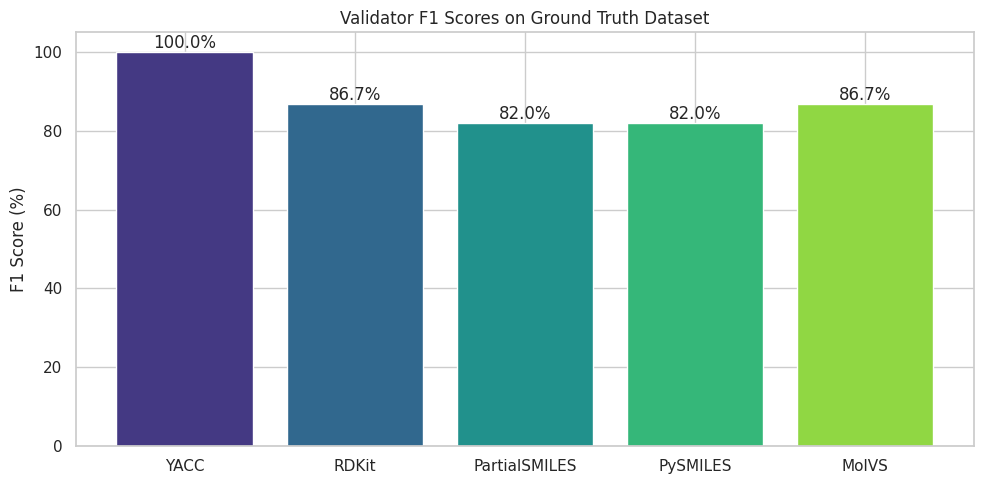

In [32]:
# Bar chart of F1 scores
fig, ax = plt.subplots(figsize=(10, 5))
f1_values = [float(m['F1'].strip('%')) for m in metrics]
colors = sns.color_palette('viridis', len(VALIDATORS))
bars = ax.bar([m['Validator'] for m in metrics], f1_values, color=colors)
ax.set_ylabel('F1 Score (%)')
ax.set_title('Validator F1 Scores on Ground Truth Dataset')
ax.set_ylim(0, 105)
for bar, val in zip(bars, f1_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('f1_scores.png', dpi=150)
plt.show()

### Confusion Matrices

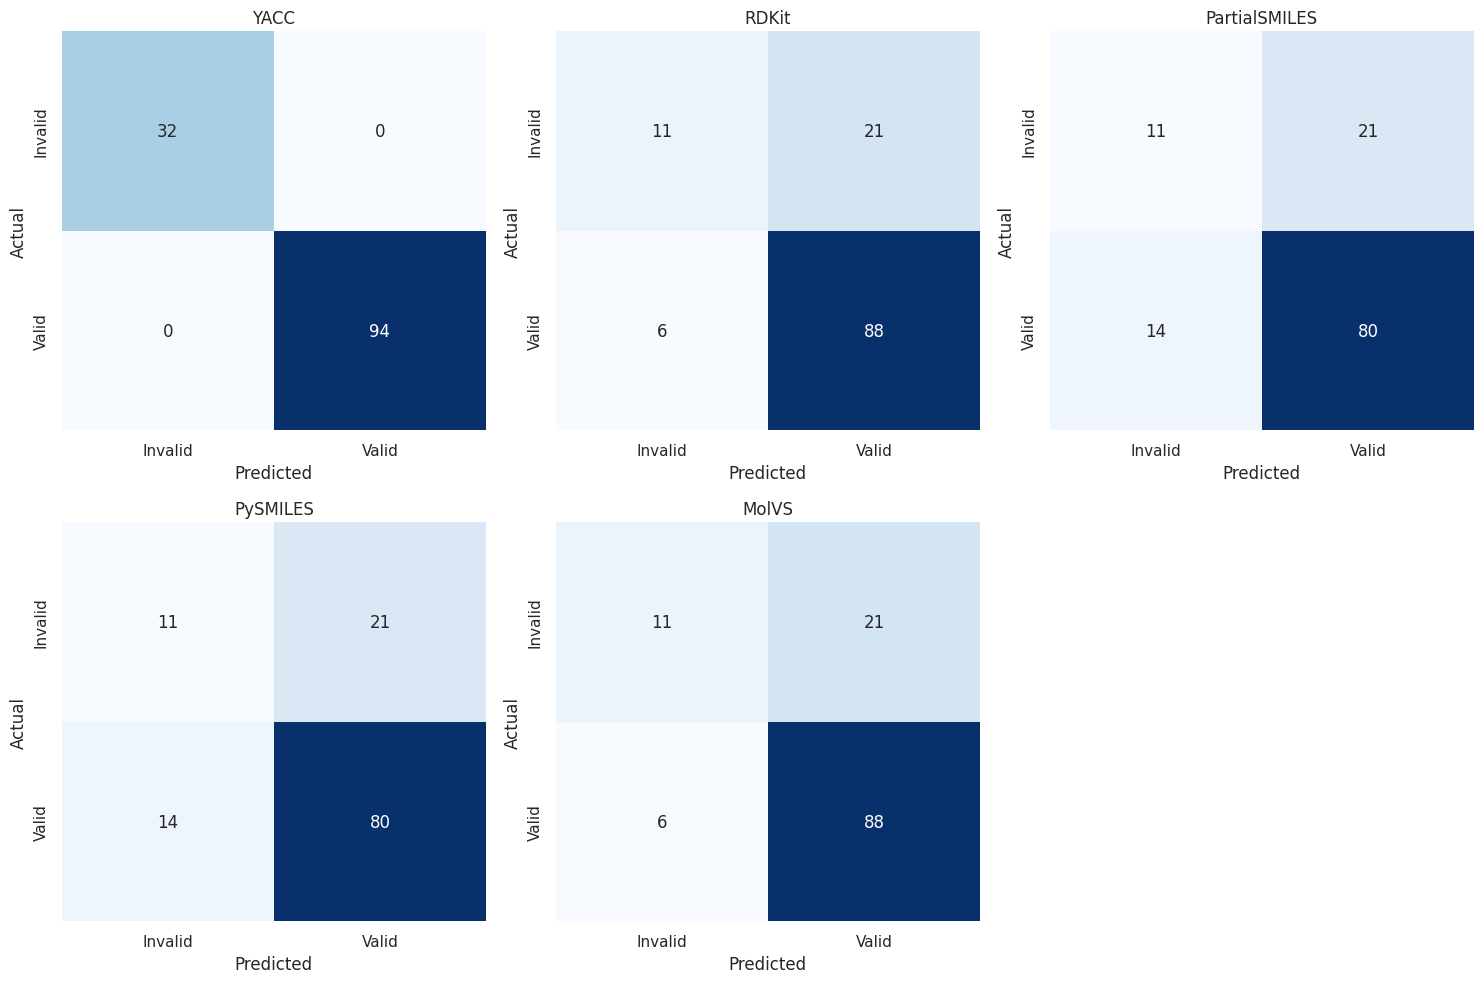

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, name in zip(axes, VALIDATORS.keys()):
    cm = pd.crosstab(test_df['ground_truth'], test_df[name], 
                     rownames=['Actual'], colnames=['Predicted'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{name}')
    ax.set_xticklabels(['Invalid', 'Valid'])
    ax.set_yticklabels(['Invalid', 'Valid'])

axes[-1].axis('off')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

### False Positives Table

In [34]:
fp_counts = {name: ((test_df['ground_truth'] == False) & (test_df[name] == True)).sum() for name in VALIDATORS}
fp_df = pd.DataFrame(list(fp_counts.items()), columns=['Validator', 'False Positives']).sort_values('False Positives')
display(fp_df)

print("\nFalse Positives by Validator:")
for name in VALIDATORS:
    fps = test_df[(test_df['ground_truth'] == False) & (test_df[name] == True)]['smiles'].tolist()
    if fps:
        print(f"\n{name} ({len(fps)}):")
        for s in fps[:5]:
            print(f"  {s[:60]}")

,Validator,False Positives
0,YACC,0
1,RDKit,21
2,PartialSMILES,21
3,PySMILES,21
4,MolVS,21



False Positives by Validator:

RDKit (21):
  c1ccc2ccccc2c1C
  c1ccc2c3ccccc3Cc2c1C
  c1cc2c3c(cccc3c1)CC2C
  c1cc2c3c(cccc3c1)C=C2C
  c1ccc2cc3ccccc3cc2c1C

PartialSMILES (21):
  c1ccc2ccccc2c1C
  c1ccc2c3ccccc3Cc2c1C
  c1cc2c3c(cccc3c1)CC2C
  c1cc2c3c(cccc3c1)C=C2C
  c1ccc2cc3ccccc3cc2c1C

PySMILES (21):
  c1ccc2ccccc2c1C
  c1ccc2c3ccccc3Cc2c1C
  c1cc2c3c(cccc3c1)CC2C
  c1cc2c3c(cccc3c1)C=C2C
  c1ccc2cc3ccccc3cc2c1C

MolVS (21):
  c1ccc2ccccc2c1C
  c1ccc2c3ccccc3Cc2c1C
  c1cc2c3c(cccc3c1)CC2C
  c1cc2c3c(cccc3c1)C=C2C
  c1ccc2cc3ccccc3cc2c1C


### False Negatives Table

In [35]:
fn_counts = {name: ((test_df['ground_truth'] == True) & (test_df[name] == False)).sum() for name in VALIDATORS}
fn_df = pd.DataFrame(list(fn_counts.items()), columns=['Validator', 'False Negatives']).sort_values('False Negatives')
display(fn_df)

,Validator,False Negatives
0,YACC,0
1,RDKit,6
4,MolVS,6
2,PartialSMILES,14
3,PySMILES,14


## 2. Large Dataset Benchmark

In [36]:
def load_benchmark_data():
    files = glob('../data/*.csv')
    results = []
    for csv in files:
        try:
            df = pd.read_csv(csv)
        except UnicodeDecodeError:
            df = pd.read_csv(csv, compression='gzip')
        if 'smiles' not in df.columns:
            continue
        dataset_name = csv.split('/')[-1].replace('.csv', '')
        for smiles in df['smiles'].dropna():
            results.append({'dataset': dataset_name, 'smiles': smiles})
        print(f"Loaded {dataset_name}: {len(df)} molecules")
    return pd.DataFrame(results)

bench_df = load_benchmark_data()
print(f"\nTotal: {len(bench_df)} molecules")

Loaded sider: 1427 molecules
Loaded mutagenicity: 4337 molecules
Loaded tox21: 7831 molecules
Loaded muv: 93087 molecules
Loaded clintox: 1484 molecules

Total: 108166 molecules


In [37]:
# Run all validators
for name, validator in VALIDATORS.items():
    print(f"Running {name}...")
    bench_df[name] = bench_df['smiles'].apply(validator)

Running YACC...
Running RDKit...


[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] WARNING: not removing hydrogen atom without neighbors
[13:43:17] Explicit valence for atom # 8 Al, 6, is greater than permitted
[13:43:18] Expli

Running PartialSMILES...
Running PySMILES...
Running MolVS...


[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:45] WARNING: not removing hydrogen atom without neighbors
[13:46:48] WARNING: not removing hydrogen atom without neighbors
[13:46:48] Explicit valence for atom # 8 Al, 6, is greater than permitted
[13:46:49] Expli

### Validation Rates by Dataset

In [38]:
summary = bench_df.groupby('dataset').agg(
    {**{'smiles': 'count'}, **{name: 'mean' for name in VALIDATORS}}
).rename(columns={'smiles': 'count'})
for name in VALIDATORS:
    summary[name] = (summary[name] * 100).round(2)
display(summary)

,count,YACC,RDKit,PartialSMILES,PySMILES,MolVS
dataset,,,,,,
clintox,1484,28.50,99.73,98.25,93.73,45.75
mutagenicity,4337,78.03,100.00,99.91,99.98,93.13
muv,93087,84.88,100.00,100.00,94.74,100.00
sider,1427,48.00,100.00,96.57,97.41,86.12
tox21,7831,74.14,99.90,98.86,97.37,91.83


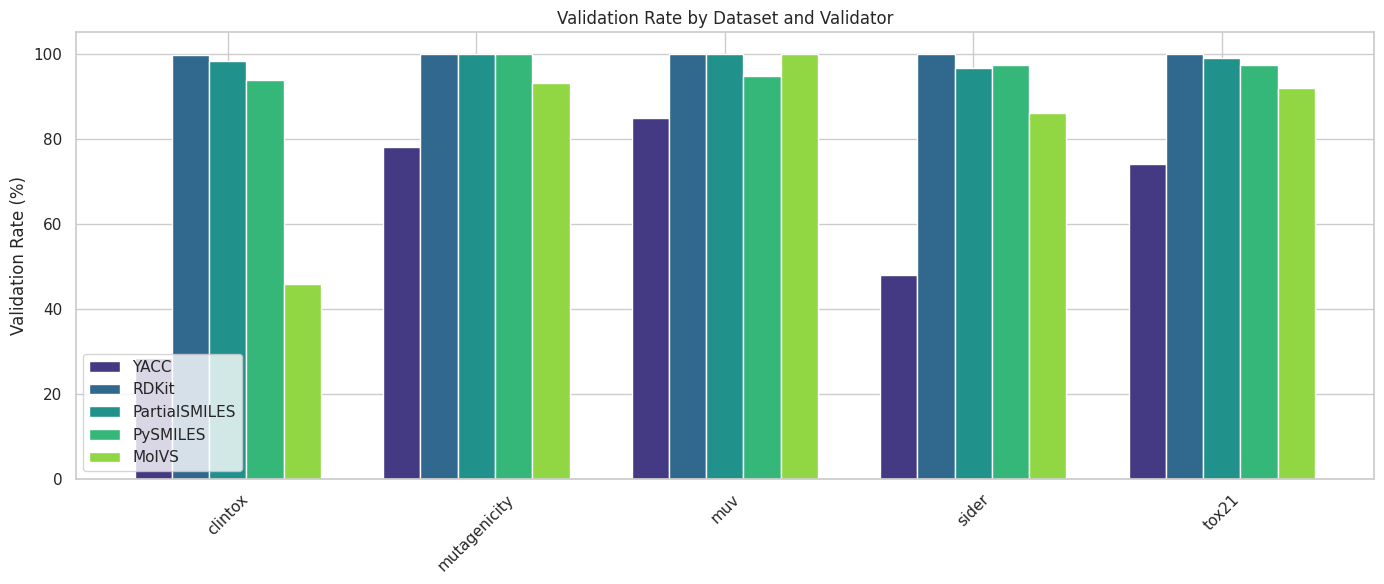

In [39]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(summary))
width = 0.15
colors = sns.color_palette('viridis', len(VALIDATORS))

for i, name in enumerate(VALIDATORS):
    offset = (i - len(VALIDATORS)/2 + 0.5) * width
    ax.bar(x + offset, summary[name], width, label=name, color=colors[i])

ax.set_ylabel('Validation Rate (%)')
ax.set_title('Validation Rate by Dataset and Validator')
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=45)
ax.legend(loc='lower left')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('validation_rates.png', dpi=150)
plt.show()

### Overall Pass Rates

In [40]:
total = len(bench_df)
pass_rates = {name: bench_df[name].sum() / total * 100 for name in VALIDATORS}
pass_df = pd.DataFrame(list(pass_rates.items()), columns=['Validator', 'Pass Rate (%)']).sort_values('Pass Rate (%)', ascending=False)
pass_df['Pass Rate (%)'] = pass_df['Pass Rate (%)'].round(2)
display(pass_df)

,Validator,Pass Rate (%)
1,RDKit,99.99
2,PartialSMILES,99.84
4,MolVS,98.20
3,PySMILES,95.16
0,YACC,82.56


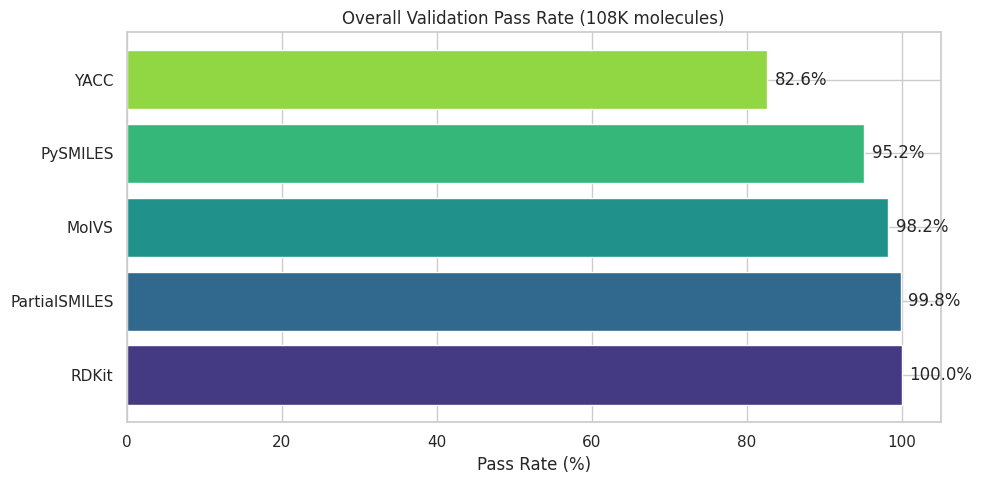

In [41]:
# Horizontal bar chart of pass rates
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('viridis', len(pass_df))
ax.barh(pass_df['Validator'], pass_df['Pass Rate (%)'], color=colors)
ax.set_xlabel('Pass Rate (%)')
ax.set_title('Overall Validation Pass Rate (108K molecules)')
ax.set_xlim(0, 105)
for i, val in enumerate(pass_df['Pass Rate (%)']):
    ax.text(val + 1, i, f'{val:.1f}%', va='center')
plt.tight_layout()
plt.savefig('pass_rates.png', dpi=150)
plt.show()

### Agreement Heatmap

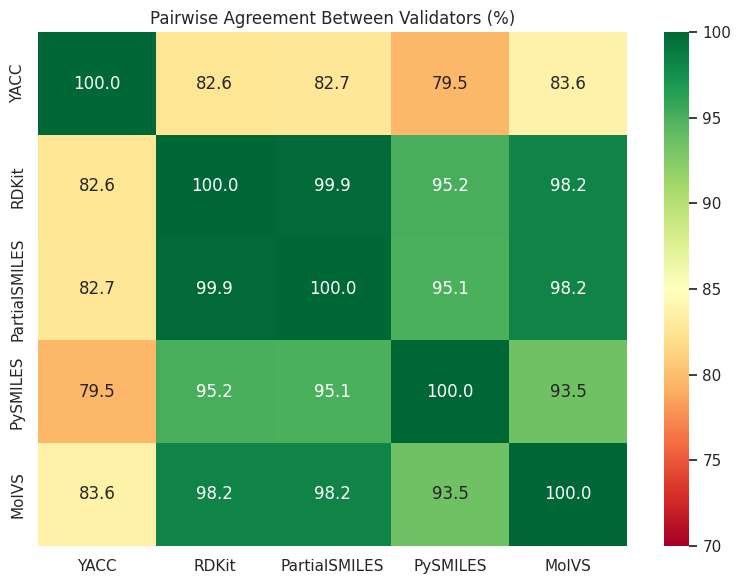

In [42]:
# Pairwise agreement between validators
agreement_matrix = pd.DataFrame(index=VALIDATORS.keys(), columns=VALIDATORS.keys(), dtype=float)
for v1 in VALIDATORS:
    for v2 in VALIDATORS:
        agreement = (bench_df[v1] == bench_df[v2]).mean() * 100
        agreement_matrix.loc[v1, v2] = agreement

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(agreement_matrix.astype(float), annot=True, fmt='.1f', cmap='RdYlGn', ax=ax, vmin=70, vmax=100)
ax.set_title('Pairwise Agreement Between Validators (%)')
plt.tight_layout()
plt.savefig('agreement_heatmap.png', dpi=150)
plt.show()

### YACC Rejection Reasons

In [43]:
yacc_rejects = bench_df[bench_df['YACC'] == False]['smiles'].head(500)

failure_reasons = []
for smiles in yacc_rejects:
    _, err = validate_smiles(smiles)
    if err:
        err_str = str(err)
        if 'validate_smiles' in err_str:
            failure_reasons.append('Trailing C Check')
        elif 'validate_rings_and_valency' in err_str:
            failure_reasons.append('Valency Check')
        elif 'validate_aromaticity' in err_str:
            failure_reasons.append('Aromaticity Check')
        elif 'chain' in err_str or 'Parser' in err_str:
            failure_reasons.append('Parsing Error')
        else:
            failure_reasons.append('Other')

reason_df = pd.DataFrame(Counter(failure_reasons).items(), columns=['Reason', 'Count']).sort_values('Count', ascending=False)
reason_df['%'] = (reason_df['Count'] / reason_df['Count'].sum() * 100).round(1)
display(reason_df)

,Reason,Count,%
0,Trailing C Check,196,39.2
1,Valency Check,109,21.8
3,Parsing Error,107,21.4
2,Aromaticity Check,88,17.6


## 3. Summary

In [44]:
print("="*60)
print("SUMMARY")
print("="*60)
print(f"Ground truth test set: {len(test_df)} molecules")
print(f"Benchmark dataset: {len(bench_df):,} molecules")
print()
print("Ground Truth Performance (F1 Score):")
for m in sorted(metrics, key=lambda x: -float(x['F1'].strip('%'))):
    print(f"  {m['Validator']:15} {m['F1']}")
print()
print("Benchmark Pass Rates:")
for _, row in pass_df.iterrows():
    print(f"  {row['Validator']:15} {row['Pass Rate (%)']:.2f}%")

SUMMARY
Ground truth test set: 126 molecules
Benchmark dataset: 108,166 molecules

Ground Truth Performance (F1 Score):
  YACC            100.00%
  RDKit           86.70%
  MolVS           86.70%
  PartialSMILES   82.05%
  PySMILES        82.05%

Benchmark Pass Rates:
  RDKit           99.99%
  PartialSMILES   99.84%
  MolVS           98.20%
  PySMILES        95.16%
  YACC            82.56%
